# AFD thermosensory encoding models: cross-validated comparison (sinusoidal up-ramp stimulus, Tc25)

Code accompanying *Goal-Dependent Gain Modulation Drives Thermosensory Responses in Behavior* (Diaz Garcia & Beagan et al., 2026).

The notebook fits six models of AFD calcium dynamics (Models A-F, labelled as in the manuscript) to the calcium recordings of animals cultivated at 25 °C (Tc25) and exposed to the sinusoidal up-ramp temperature stimulus and compares them by worm-level cross-validation.

**Models** (all of them output a latent trace C(t); the predicted calcium signal is F = a·C(t) + b, with a and b fit per worm)

| Model | Description |
|---|---|
| A | Baseline Derivative: leaky integration of dT/dt |
| B | Fold Change Detection with a fitted reference temperature: leaky integration of (1/(T − T_ref))·dT/dt |
| C | Feedback-like Divisive Normalization |
| D | Sigmoid/Threshold |
| E | Adaptive Threshold (Levy & Bargmann 2020) with a fitted reference temperature T_ref |
| F | Goal-Dependent Gain: leaky derivative multiplied by a gamma-shaped gain window above T_on |

**Sections**

1. Configuration and helper functions
2. Data loading
3. Model definitions
4. Per-worm fits of Models A-F
5. LN test (calcium vs. Model A drive)
6. Worm-level cross-validation, statistical comparison with Model F and figure of held-out R²
7. Held-out R² of Model A vs. Model F (Fig. 5F′/G′)
8. Cross-validation parameter stability (Table S2)
9. Diagnostics of the reference-temperature models (B and E)
10. Representative fitted traces (Fig. S7A,B)

**Input.** A CSV file in `data/` with one time column (name containing "time"), one temperature column (name containing "temp") and one column per worm whose name starts with "Rep". Settings (file name, number of Optuna trials, cross-validation scheme, statistics, figure output) are in the first code cell. Figures are written as SVG to `results/`.

**Requirements.** Python 3 with numpy, pandas, scipy, matplotlib, optuna and IPython.

In [1]:
# 1. Configuration, imports and shared helpers

import hashlib
import os
import random
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter
from scipy.special import expit
from scipy.stats import gamma as scipy_gamma
from scipy.stats import mannwhitneyu

optuna.logging.set_verbosity(optuna.logging.WARNING)
mpl.rcParams["svg.fonttype"] = "none"   # keep SVG text editable
mpl.rcParams["svg.hashsalt"] = "0"
plt.close("all")

# ---- Data ----
dataset = "Sinusoidal upramp Tc25"            # figure label; also part of the random seeds, so do not change
DATA_DIR = r"/Users/sk3526/Library/CloudStorage/OneDrive-YaleUniversity/github_repos/Diaz-Garcia-and-Beagan-et-al.-2026-AFD-/AFD_modeling_Fig_2_5_S4"
DATA_FILENAME = "upramp_Tc25.csv"

T_START = 30.0                   # analysis window (s)
T_END = 3000.0                   # None = to the end of the recording
TEMP_SMOOTH_WINDOW_SEC = 3.0     # Savitzky-Golay window for the temperature trace (s)
TEMP_SMOOTH_POLYORDER = 2
DROP_INITIAL_SECONDS = 10.0      # excluded from every fit and every R2

# ---- Fitting ----
N_TRIALS_PER_WORM = 300          # Optuna trials per worm and model (per-worm fits)
N_TRIALS_CV = 300                # Optuna trials per training fold and model (cross-validation)
CV_MODE = "kfold"                # "kfold" or "loo"
CV_N_SPLITS = 5                  # used only if CV_MODE = "kfold"
CV_RANDOM_SEED = 1
SHOW_OPTUNA_PROGRESS = False

# ---- Statistics ----
REFERENCE_MODEL_ID = "full_gamma"            # Model F; every other model is compared with it
MULTIPLE_COMPARISON_METHOD = "bonferroni"    # "bonferroni" or "holm"; sets the significance labels

# ---- Figures ----
SAVE_FIGURES = True              # save every figure as SVG in OUTPUT_DIR
OUTPUT_DIR = "results"
REPRESENTATIVE_FIT_SELECTION = "best_model_f"   # "best_model_f", "median_model_f" or "manual"
REPRESENTATIVE_REP_IDX = None                   # 0-based worm index, used only for "manual"


def save_svg(fig, filename):
    """Save a figure as SVG in OUTPUT_DIR when SAVE_FIGURES is True."""
    if not SAVE_FIGURES:
        return
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format="svg", bbox_inches="tight")
    print(f"Saved {path}")


def safe_label(text):
    """Filename-safe version of a dataset or replicate name."""
    return re.sub(r"[^A-Za-z0-9_-]+", "_", str(text)).strip("_")


def stable_seed(*parts, base=1, mod=2**31 - 1):
    """Deterministic integer seed from arbitrary strings/ints; stable across runs and machines."""
    s = "|".join(str(p) for p in parts)
    h = hashlib.md5(s.encode("utf-8")).hexdigest()
    return (base + int(h[:8], 16)) % mod


def set_all_seeds(seed):
    seed = int(seed)
    np.random.seed(seed)
    random.seed(seed)


def fit_gain_offset(model, data):
    """Least-squares a, b such that data ~ a * model + b. NaN-safe."""
    model = np.asarray(model, dtype=float)
    data = np.asarray(data, dtype=float)
    m = np.isfinite(model) & np.isfinite(data)
    if m.sum() < 3:
        return np.nan, np.nan
    A = np.vstack([model[m], np.ones_like(model[m])]).T
    a, b = np.linalg.lstsq(A, data[m], rcond=None)[0]
    return a, b


def r2_nan(y_true, y_pred):
    """NaN-safe R^2."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 3:
        return np.nan
    yt = y_true[m]
    yp = y_pred[m]
    ss_res = np.sum((yt - yp) ** 2)
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)
    if ss_tot <= 0:
        return np.nan
    return 1.0 - ss_res / ss_tot


def mean_sem(x):
    """Mean and SEM of the finite values (SEM = 0 for a single value)."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan
    if x.size == 1:
        return float(x[0]), 0.0
    return float(x.mean()), float(x.std(ddof=1) / np.sqrt(x.size))


def adjust_pvalues(pvals, method="bonferroni"):
    """
    Multiple-comparison correction across one family of tests.
    NaN p-values are ignored and stay NaN; m = number of finite p-values.
      bonferroni: p_adj = min(1, m * p)
      holm:       step-down Bonferroni (never less powerful than Bonferroni)
    """
    p = np.asarray(pvals, dtype=float)
    adj = np.full(p.shape, np.nan)
    ok = np.isfinite(p)
    m = int(ok.sum())
    if m == 0:
        return adj
    method = str(method).lower()
    if method == "bonferroni":
        adj[ok] = np.minimum(1.0, p[ok] * m)
    elif method == "holm":
        idx = np.flatnonzero(ok)
        order = idx[np.argsort(p[idx], kind="stable")]
        scaled = (m - np.arange(m)) * p[order]
        adj[order] = np.minimum(1.0, np.maximum.accumulate(scaled))
    else:
        raise ValueError('method must be "bonferroni" or "holm"')
    return adj


def sig_label(p):
    """Significance label for a (corrected) p-value."""
    if not np.isfinite(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."

Loaded: Sinusoidal upramp Tc25
File: /Users/sk3526/Library/CloudStorage/OneDrive-YaleUniversity/github_repos/Diaz-Garcia-and-Beagan-et-al.-2026-AFD-/AFD_modeling_Fig_2_5_S4/upramp_Tc25.csv
Time window: 30.10 - 2100.35 s; dt mean = 0.1000 s
Worms/replicates: 17
Savitzky-Golay temperature smoothing: window = 31 samples (~3.10 s), polyorder = 2
Saved results/Sinusoidal_upramp_Tc25_stimulus_overview.svg


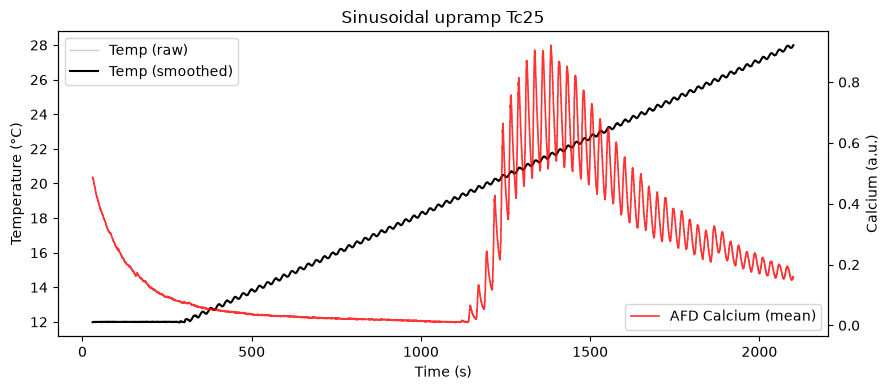

In [2]:
# 2. Load data: crop to the analysis window and smooth the temperature trace

file_path = os.path.join(DATA_DIR, DATA_FILENAME)
df = pd.read_csv(file_path)

# Detect columns: one time column, one temperature column and Rep_* calcium columns
time_candidates = [c for c in df.columns if "time" in c.lower()]
temp_candidates = [c for c in df.columns if "temp" in c.lower()]
rep_cols = [c for c in df.columns if c.lower().startswith("rep")]

if len(time_candidates) == 0:
    raise ValueError(f"No time column found. Columns are: {list(df.columns)}")
if len(temp_candidates) == 0:
    raise ValueError(f"No temperature column found. Columns are: {list(df.columns)}")
if len(rep_cols) == 0:
    raise ValueError(f"No Rep_* columns found. Columns are: {list(df.columns)}")

Time_ramp = df[time_candidates[0]].to_numpy(dtype=float)
Temp_raw = df[temp_candidates[0]].to_numpy(dtype=float)
Ca_mat = df[rep_cols].to_numpy(dtype=float)   # shape (T, n_worms)

# Drop replicate columns that are entirely NaN
valid_rep_mask = ~np.all(np.isnan(Ca_mat), axis=0)
Ca_mat = Ca_mat[:, valid_rep_mask]
rep_cols = [c for c, ok in zip(rep_cols, valid_rep_mask) if ok]

# Crop to the analysis window
if T_END is None:
    mask_time = Time_ramp >= T_START
else:
    mask_time = (Time_ramp >= T_START) & (Time_ramp <= T_END)

if mask_time.sum() < 10:
    raise RuntimeError(
        f"Time crop failed: only {mask_time.sum()} points left. "
        f"Check T_START={T_START}, T_END={T_END}, "
        f"time range=[{Time_ramp.min():.2f}, {Time_ramp.max():.2f}]"
    )

Time_ramp = Time_ramp[mask_time]
Temp_raw = Temp_raw[mask_time]
Ca_mat = Ca_mat[mask_time, :]

# Savitzky-Golay smoothing of the temperature trace (measurement noise only)
dt = float(np.mean(np.diff(Time_ramp)))
win_len = int(round(TEMP_SMOOTH_WINDOW_SEC / dt))
if win_len % 2 == 0:
    win_len += 1
win_len = max(win_len, TEMP_SMOOTH_POLYORDER + 2)

Temp_ramp = savgol_filter(
    Temp_raw,
    window_length=win_len,
    polyorder=TEMP_SMOOTH_POLYORDER,
    mode="interp",
)

# Arrays used by every analysis below
Time = np.asarray(Time_ramp, dtype=float)
Temp = np.asarray(Temp_ramp, dtype=float)
n_worms = int(Ca_mat.shape[1])

# Time points used for every fit and every R2
FIT_MASK = Time >= (float(Time[0]) + float(DROP_INITIAL_SECONDS))
if np.sum(FIT_MASK) < 10:
    raise RuntimeError("Too few time points after DROP_INITIAL_SECONDS.")

print(f"Loaded: {dataset}")
print(f"File: {file_path}")
print(f"Time window: {Time[0]:.2f} - {Time[-1]:.2f} s; dt mean = {dt:.4f} s")
print(f"Worms/replicates: {n_worms}")
print(f"Savitzky-Golay temperature smoothing: window = {win_len} samples "
      f"(~{win_len * dt:.2f} s), polyorder = {TEMP_SMOOTH_POLYORDER}")

# Overview: temperature (raw and smoothed) and mean calcium
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(Time, Temp_raw, color="gray", alpha=0.4, linewidth=1.0, label="Temp (raw)")
ax1.plot(Time, Temp, "k", linewidth=1.5, label="Temp (smoothed)")
ax2.plot(Time, np.nanmean(Ca_mat, axis=1), "r", alpha=0.8, linewidth=1.2, label="AFD Calcium (mean)")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Temperature (°C)")
ax2.set_ylabel("Calcium (a.u.)")
ax1.legend(loc="upper left")
ax2.legend(loc="lower right")
plt.title(f"{dataset}")
plt.tight_layout()
save_svg(fig, f"{safe_label(dataset)}_stimulus_overview.svg")
plt.show()

## Models

Temperature T(t) is smoothed with a Savitzky-Golay filter. D(t) is the leaky derivative of temperature, τ_D·dD/dt = dT/dt − D. Every model is evaluated from the current and past temperature only.

- **Model A, Baseline Derivative:** C(t) = D(t)
- **Model B, Fold Change Detection:** the derivative is normalized by the distance from a fitted reference temperature, u(t) = (dT/dt) / (T(t) − T_ref), and passed through the same leaky integrator; T_ref is constrained to lie below every stimulus temperature
- **Model C, Feedback-like Divisive Normalization:** C(t) = D(t) / (1 + k·A(t)), where A is a slower low-pass filter of |D|
- **Model D, Sigmoid/Threshold:** C(t) = D(t) · sigmoid(s·(T(t) − T_thr))
- **Model E, Adaptive Threshold:** S(t) = max(T_ref − T(t), 0); θ_tar = K·(1 − exp(−S/K)); τ·dθ/dt = θ_tar − θ; C(t) = max(θ − S, 0); T_ref is a fitted parameter that may lie inside the stimulus range
- **Model F, Goal-Dependent Gain:** C(t) = D(t) · W(T(t)), where W is a gamma-shaped window above T_on

In [3]:
# 3. Model definitions (Models A-F)
#
# Every model returns a latent trace C(t); the readout is a * C(t) + b, with a and b fit per worm.
# Model labels are those of the manuscript (Fig. S6, Fig. S7, Table S1).

TAU_MIN = 1e-2
TAU_MAX = 1e3


def safe_tau(x):
    return float(np.clip(x, TAU_MIN, TAU_MAX))


def _run_one_pole(signal, alphas, init=0.0):
    """
    out[0] = init;  out[i] = out[i-1] + alphas[i-1] * (signal[i] - out[i-1])
    Plain-float loop: same arithmetic, in the same order, as a NumPy element-wise loop.
    """
    x = np.asarray(signal, dtype=float).tolist()
    out = [float(init)] * len(x)
    prev = float(init)
    for i in range(1, len(x)):
        prev = prev + alphas[i - 1] * (x[i] - prev)
        out[i] = prev
    return np.asarray(out, dtype=float)


def _step_alphas(time, tau):
    """
    Per-step filter coefficient 1 - exp(-dt_i / tau), with dt_i = time[i] - time[i-1].
    The exponential is evaluated once per distinct dt value rather than at every sample.
    """
    dts = np.diff(np.asarray(time, dtype=float))
    ok = np.isfinite(dts) & (dts > 0)
    default_dt = float(np.nanmedian(dts[ok])) if np.any(ok) else 1.0
    cache = {}
    alphas = []
    for d, good in zip(dts.tolist(), ok.tolist()):
        if not good:
            d = default_dt
        a = cache.get(d)
        if a is None:
            a = float(1.0 - np.exp(-d / tau))
            cache[d] = a
        alphas.append(a)
    return alphas


# ---------------- Models A and F ----------------

def raw_derivative_mean_dt(Time, Temp):
    """dT/dt with the mean sampling interval (Models A and F)."""
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    dt = float(np.mean(np.diff(Time)))
    dT_raw = np.zeros(Time.size, dtype=float)
    dT_raw[1:] = np.diff(Temp) / dt
    return dT_raw, dt


def model_a_baseline_derivative(Time, Temp, tauD):
    """Model A (baseline derivative): tauD * dD/dt = dT/dt - D;  C(t) = D(t)."""
    if np.asarray(Time).size < 2:
        return np.full(np.asarray(Time).shape, np.nan, dtype=float)
    dT_raw, dt = raw_derivative_mean_dt(Time, Temp)
    alpha = float(1.0 - np.exp(-dt / safe_tau(tauD)))
    return _run_one_pole(dT_raw, [alpha] * (dT_raw.size - 1))


def gamma_window(Temp, T_on, k_shape, k_scale):
    Temp = np.asarray(Temp, float)
    T_rel = np.clip(Temp - T_on, 0.0, None)
    W = scipy_gamma.pdf(T_rel, a=k_shape, scale=k_scale)
    mx = np.max(W)
    return W / (mx + 1e-9)


def model_f_goal_dependent_gain(Time, Temp, tauD, T_on, k_shape, k_scale):
    """Model F (goal-dependent gain): C(t) = D(t) * W(T(t)), D as in Model A, W a Gamma-shaped gain window above T_on."""
    D = model_a_baseline_derivative(Time, Temp, tauD)
    return D * gamma_window(Temp, T_on, k_shape, k_scale)


# ---------------- Models B, C, D and E ----------------

def numerical_derivative(time, signal):
    """NaN-safe numerical derivative using the per-step sampling interval."""
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)
    d = np.zeros_like(signal, dtype=float)
    dt = np.diff(time)
    finite_dt = np.isfinite(dt) & (dt != 0)
    fallback_dt = float(np.nanmedian(dt[finite_dt])) if np.any(finite_dt) else 1.0
    dt[~finite_dt] = fallback_dt
    d[1:] = np.diff(signal) / dt
    return d


def one_pole_filter(time, signal, tau):
    """One-pole low-pass filter (exact solution of the linear ODE over each step)."""
    tau = float(max(tau, 1e-6))
    return _run_one_pole(signal, _step_alphas(time, tau))


def fcd_kelvin_drive(Time, Temp, tauD):
    """
    Fold-change detection on the Kelvin scale. Not a fitted model: used only by the diagnostic in
    section 9 (similarity of the Kelvin form to Model A).

        u(t)         = (1 / T_K(t)) * dT/dt = d/dt ln T_K(t),   T_K(t) = T(t) + 273
        tauD * dD/dt = u(t) - D(t)                              readout: a * D(t) + b

    The normalization uses the INSTANTANEOUS absolute temperature T_K(t), not a fixed 273 K.
    """
    T_kelvin = np.asarray(Temp, dtype=float) + 273.0
    dlogT = numerical_derivative(Time, np.log(np.clip(T_kelvin, 1e-9, None)))
    return one_pole_filter(Time, dlogT, tauD)


def model_b_fcd_reference_temperature(Time, Temp, tauD, T_ref_FCD):
    """
    Model B: fold-change detection with a fitted reference temperature.

        u(t)         = (1 / (T(t) - T_ref)) * dT/dt = d/dt ln(T(t) - T_ref)
        tauD * dD/dt = u(t) - D(t)                    readout: a * D(t) + b

    T_ref is a static fitted parameter constrained below every stimulus temperature.
    At T_ref = -273 C this is the Kelvin form. Uses only T(s) for s <= t.
    """
    Temp = np.asarray(Temp, dtype=float)
    denom = Temp - float(T_ref_FCD)
    finite = np.isfinite(denom)
    if (not np.any(finite)) or np.any(denom[finite] <= 0.0):
        return np.full_like(Temp, np.nan, dtype=float)
    u = numerical_derivative(Time, np.log(denom))
    return one_pole_filter(Time, u, tauD)


def model_c_feedback_normalization(Time, Temp, tauD, tauA, norm_k):
    """
    Model C: feedback/adaptive-scaling-like control.
    A leaky derivative drive D is compressed by a slower adaptation variable A:
        A = LPF_tauA(|D|),   C(t) = D / (1 + norm_k * A)
    """
    dT = numerical_derivative(Time, Temp)
    D = one_pole_filter(Time, dT, tauD)
    A = one_pole_filter(Time, np.abs(D), tauA)
    return D / (1.0 + float(norm_k) * np.maximum(A, 0.0))


def model_d_sigmoid_threshold(Time, Temp, tauD, T_thr, sigmoid_slope):
    """
    Model D: threshold/sigmoid control.
    A leaky derivative drive is multiplied by a smooth temperature threshold:
        C(t) = D(t) * sigmoid(sigmoid_slope * (T(t) - T_thr))
    """
    dT = numerical_derivative(Time, Temp)
    D = one_pole_filter(Time, dT, tauD)
    W = expit(float(sigmoid_slope) * (np.asarray(Temp, dtype=float) - float(T_thr)))
    return D * W


def act_threshold_core(Time, S, tau_ACT, K_ACT):
    """ACT adaptive threshold (Levy & Bargmann 2020) driven by a non-negative input S(t); causal."""
    S = np.asarray(S, dtype=float)
    tau_ACT = float(max(tau_ACT, 1e-6))
    K_ACT = float(max(K_ACT, 1e-9))
    target = K_ACT * (1.0 - np.exp(-S / K_ACT))          # steady-state threshold for the current input
    # Dynamic threshold, initialized at steady state for the first sample.
    theta = _run_one_pole(target, _step_alphas(Time, tau_ACT), init=target[0])
    return np.maximum(theta - S, 0.0)


def model_e_adaptive_threshold(Time, Temp, tau_ACT, K_ACT, T_ref_ACT):
    """
    Model E: adaptive threshold (Levy & Bargmann 2020) with a fitted reference temperature.

        S(t)                = max(T_ref - T(t), 0)
        Theta_inf(t)        = K_ACT * (1 - exp(-S(t) / K_ACT))
        tau_ACT dTheta/dt   = Theta_inf(t) - Theta(t),      Theta(0) = Theta_inf(0)
        C(t)                = max(Theta(t) - S(t), 0)        readout: a * C(t) + b

    Fitted biological parameters: tau_ACT, K_ACT, T_ref_ACT. Only T(s), s <= t, is used.
    T_ref may fall inside the stimulus range; S(t) is then clipped at 0 above T_ref.
    """
    S = np.maximum(float(T_ref_ACT) - np.asarray(Temp, dtype=float), 0.0)
    return act_threshold_core(Time, S, tau_ACT, K_ACT)


# ---------------- Model registry ----------------

MODEL_CONFIGS = [
    {"id": "deriv_tau",             "name": "Model A", "description": "Baseline derivative"},
    {"id": "fcd_tref",              "name": "Model B", "description": "FCD, fitted T_ref below stimulus"},
    {"id": "feedback_norm",         "name": "Model C", "description": "Feedback-like divisive normalization"},
    {"id": "threshold_sig",         "name": "Model D", "description": "Sigmoid/threshold"},
    {"id": "act_threshold_relaxed", "name": "Model E", "description": "Adaptive threshold, T_ref within range"},
    {"id": "full_gamma",            "name": "Model F", "description": "Goal-dependent gain"},
]
MODEL_IDS = [cfg["id"] for cfg in MODEL_CONFIGS]
MODEL_NAME = {cfg["id"]: cfg["name"] for cfg in MODEL_CONFIGS}
MODEL_DESCRIPTION = {cfg["id"]: cfg["description"] for cfg in MODEL_CONFIGS}
SEED_BASE_A_F_IDS = ["deriv_tau", "full_gamma"]   # Models A and F (see section 4)
REFERENCE_MODEL_NAME = MODEL_NAME[REFERENCE_MODEL_ID]

MODEL_COLORS = {
    "deriv_tau":             "#f0c571",
    "full_gamma":            "#a559aa",
    "fcd_tref":              "#4f7fa8",
    "feedback_norm":         "#95c47f",
    "threshold_sig":         "#d98b72",
    "act_threshold_relaxed": "#bcc3ea",
}

# ---------------- Parameter search ranges ----------------
# Temperature range of the fitted samples and of the full trace
T_MIN_FIT = float(np.nanmin(Temp[FIT_MASK]))
T_MAX_FIT = float(np.nanmax(Temp[FIT_MASK]))
T_RANGE_FIT = max(T_MAX_FIT - T_MIN_FIT, 1e-3)
T_MIN_FULL = float(np.nanmin(Temp))
T_MAX_FULL = float(np.nanmax(Temp))

# Bounds on the reference temperatures. These constrain static fitted parameters;
# the models themselves use only T(s) for s <= t.
# Model B: T(t) - T_ref must stay > 0, so T_ref lies below every stimulus temperature.
#   It is sampled as its distance below the coldest temperature, from 0.5 C down to
#   -273 C (where Model B corresponds to the Kelvin form).
FCD_MIN_GAP_C = 0.5
FCD_GAP_BOUNDS = (FCD_MIN_GAP_C, T_MIN_FULL + 273.0)
# Model E: T_ref may lie inside the stimulus range.
ACT_TREF_BOUNDS_RELAXED = (T_MIN_FULL, T_MAX_FULL + 10.0)
_K_ACT_BOUNDS = (max(0.01, 0.01 * T_RANGE_FIT), max(1.0, 10.0 * T_RANGE_FIT))

# model_id -> [(parameter, low, high, log_scale), ...] in the order Optuna samples them.
PARAM_SPECS = {
    "deriv_tau": [("tauD", 40.0, 60.0, True)],
    "full_gamma": [
        ("tauD", 40.0, 60.0, True),
        ("T_on", 20.0, 21.0, False),
        ("k_shape", 1.5, 8.0, False),
        ("k_scale", 0.2, 5.0, False),
    ],
    "fcd_tref": [
        ("tauD", 40.0, 60.0, True),
        ("T_ref_gap_FCD", FCD_GAP_BOUNDS[0], FCD_GAP_BOUNDS[1], True),
    ],
    "feedback_norm": [
        ("tauD", 40.0, 60.0, True),
        ("tauA", 1.0, 300.0, True),
        ("norm_k", 0.01, 200.0, True),
    ],
    "threshold_sig": [
        ("tauD", 40.0, 60.0, True),
        ("T_thr", T_MIN_FIT - 2.0, T_MAX_FIT + 2.0, False),
        ("sigmoid_slope", 0.05, 25.0, True),
    ],
    "act_threshold_relaxed": [
        ("tau_ACT", 40.0, 60.0, True),
        ("K_ACT", _K_ACT_BOUNDS[0], _K_ACT_BOUNDS[1], True),
        ("T_ref_ACT", ACT_TREF_BOUNDS_RELAXED[0], ACT_TREF_BOUNDS_RELAXED[1], False),
    ],
}
PARAM_NAMES = {mid: [spec[0] for spec in specs] for mid, specs in PARAM_SPECS.items()}

print(f"Model B: T_ref_FCD searched in [-273, {T_MIN_FULL - FCD_MIN_GAP_C:.2f}] C")
print(f"Model E: T_ref_ACT searched in [{ACT_TREF_BOUNDS_RELAXED[0]:.2f}, {ACT_TREF_BOUNDS_RELAXED[1]:.2f}] C")


def suggest_params(trial, model_id):
    """Sample the biological parameters of one model from its search ranges."""
    return {
        name: trial.suggest_float(name, low, high, log=log)
        for name, low, high, log in PARAM_SPECS[model_id]
    }


def build_model(model_id, params):
    """Latent model trace C(t) for the loaded stimulus. Identical for every worm."""
    p = {k: float(v) for k, v in params.items()}
    if model_id == "deriv_tau":
        return model_a_baseline_derivative(Time, Temp, tauD=p["tauD"])
    if model_id == "full_gamma":
        return model_f_goal_dependent_gain(
            Time, Temp, tauD=p["tauD"], T_on=p["T_on"], k_shape=p["k_shape"], k_scale=p["k_scale"])
    if model_id == "fcd_tref":
        return model_b_fcd_reference_temperature(
            Time, Temp, tauD=p["tauD"], T_ref_FCD=T_MIN_FULL - p["T_ref_gap_FCD"])
    if model_id == "feedback_norm":
        return model_c_feedback_normalization(
            Time, Temp, tauD=p["tauD"], tauA=p["tauA"], norm_k=p["norm_k"])
    if model_id == "threshold_sig":
        return model_d_sigmoid_threshold(
            Time, Temp, tauD=p["tauD"], T_thr=p["T_thr"], sigmoid_slope=p["sigmoid_slope"])
    if model_id == "act_threshold_relaxed":
        return model_e_adaptive_threshold(
            Time, Temp, tau_ACT=p["tau_ACT"], K_ACT=p["K_ACT"], T_ref_ACT=p["T_ref_ACT"])
    raise ValueError(f"Unknown model_id: {model_id}")


def trace_is_usable(C_model):
    """A latent trace can be scored only if it is finite and not constant over the fitted samples."""
    return bool(np.all(np.isfinite(C_model)) and (np.nanstd(C_model[FIT_MASK]) >= 1e-12))


def affine_score(C_model, Calcium):
    """
    Fit the per-worm readout a, b (fluorescence scale and offset) to one worm and
    return (R2, a, b, fitted trace). Biological parameters are not touched here.
    """
    nan_fit = np.full(Time.shape, np.nan, dtype=float)
    if not trace_is_usable(C_model):
        return np.nan, np.nan, np.nan, nan_fit
    a, b = fit_gain_offset(C_model[FIT_MASK], Calcium[FIT_MASK])
    if (not np.isfinite(a)) or (not np.isfinite(b)):
        return np.nan, np.nan, np.nan, nan_fit
    fit = a * C_model + b
    R2 = r2_nan(Calcium[FIT_MASK], fit[FIT_MASK])
    return float(R2), float(a), float(b), fit


def params_from_row(row, model_id):
    """Biological parameters of one model from a row of a fit/parameter table."""
    return {name: float(row[name]) for name in PARAM_NAMES[model_id]}


def unpaired_tests_vs_reference(fit_df, value_col="R2"):
    """
    Unpaired two-sided Mann-Whitney U test of every model against the reference model.
    The held-out values of the two models are treated as independent groups (worm
    identity is not used), with multiple-comparison correction across the family of tests.
    delta = reference - other.
    """
    ref = fit_df.loc[fit_df["model_id"] == REFERENCE_MODEL_ID, value_col].to_numpy(dtype=float)
    ref = ref[np.isfinite(ref)]
    rows = []
    for cfg in MODEL_CONFIGS:
        if cfg["id"] == REFERENCE_MODEL_ID:
            continue
        other = fit_df.loc[fit_df["model_id"] == cfg["id"], value_col].to_numpy(dtype=float)
        other = other[np.isfinite(other)]
        u_stat, pval = np.nan, np.nan
        if ref.size >= 2 and other.size >= 2:
            try:
                res = mannwhitneyu(ref, other, alternative="two-sided")
                u_stat, pval = float(res.statistic), float(res.pvalue)
            except Exception:
                u_stat, pval = np.nan, np.nan
        have = bool(ref.size and other.size)
        delta_mean = float(np.mean(ref) - np.mean(other)) if have else np.nan
        delta_median = float(np.median(ref) - np.median(other)) if have else np.nan
        rows.append({
            "model_id": cfg["id"],
            "comparison": f"{REFERENCE_MODEL_NAME} vs {cfg['name']}",
            "other_model_description": cfg["description"],
            "n_reference": int(ref.size),
            "n_other": int(other.size),
            f"delta_mean_{value_col}": delta_mean,          # mean(reference) - mean(other)
            f"delta_median_{value_col}": delta_median,      # median(reference) - median(other)
            "higher_" + value_col: (REFERENCE_MODEL_NAME if delta_median > 0 else cfg["name"]) if have else "",
            "mannwhitney_U": u_stat,
            "mannwhitney_p": pval,
        })
    out = pd.DataFrame(rows)
    out["p_bonferroni"] = adjust_pvalues(out["mannwhitney_p"], "bonferroni")
    out["p_holm"] = adjust_pvalues(out["mannwhitney_p"], "holm")
    p_used = out["p_bonferroni"] if MULTIPLE_COMPARISON_METHOD.lower() == "bonferroni" else out["p_holm"]
    out["label"] = [sig_label(p) for p in p_used]
    return out

Model B: T_ref_FCD searched in [-273, 11.46] C
Model E: T_ref_ACT searched in [11.96, 37.99] C


In [4]:
# 4. Per-worm fits: Models A-F, each worm fit independently (no cross-validation)
#
# Later sections (LN test, diagnostics, representative traces) read fit_df and do not refit.

# Optuna seed bases: 1 for Models A and F, 11 for Models B-E
PER_WORM_SEED_BASE_A_F = 1
PER_WORM_SEED_BASE_B_TO_E = 11


def per_worm_seed(rep_name, model_id):
    base = PER_WORM_SEED_BASE_A_F if model_id in SEED_BASE_A_F_IDS else PER_WORM_SEED_BASE_B_TO_E
    return stable_seed(dataset, rep_name, model_id, base=base)


class PerWormObjective:
    """R2 of one model on one worm; a, b are solved by least squares inside each trial."""
    def __init__(self, model_id, Calcium):
        self.model_id = model_id
        self.Calcium = np.asarray(Calcium, dtype=float)

    def __call__(self, trial):
        params = suggest_params(trial, self.model_id)
        R2 = affine_score(build_model(self.model_id, params), self.Calcium)[0]
        return float(R2) if np.isfinite(R2) else -1e9


print("=" * 80)
print(f"PER-WORM FITS - Models A-F - {dataset}")
print(f"{n_worms} worms x {len(MODEL_CONFIGS)} models; {N_TRIALS_PER_WORM} Optuna trials per fitted model")
print("=" * 80)

fit_rows = []
for rep_idx in range(n_worms):
    Calcium = np.asarray(Ca_mat[:, rep_idx], dtype=float)
    rep_name = str(rep_cols[rep_idx])
    base_row = {"rep_idx": int(rep_idx), "rep_name": rep_name}

    if np.isfinite(Calcium).sum() < 10:
        print(f"Replicate {rep_name} skipped: too few finite points")
        for cfg in MODEL_CONFIGS:
            fit_rows.append({**base_row, "model_id": cfg["id"], "model_name": cfg["name"],
                             "description": cfg["description"], "R2": np.nan, "a": np.nan, "b": np.nan})
        continue

    print(f"\nReplicate {rep_idx + 1}/{n_worms}: {rep_name}")
    for cfg in MODEL_CONFIGS:
        model_id = cfg["id"]

        seed_val = per_worm_seed(rep_name, model_id)
        set_all_seeds(seed_val)
        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=seed_val))
        study.optimize(
            PerWormObjective(model_id, Calcium),
            n_trials=N_TRIALS_PER_WORM,
            show_progress_bar=SHOW_OPTUNA_PROGRESS,
            n_jobs=1,
        )
        best_params = dict(study.best_params)

        R2, a, b, _ = affine_score(build_model(model_id, best_params), Calcium)
        fit_rows.append({**base_row, "model_id": model_id, "model_name": cfg["name"],
                         "description": cfg["description"], "R2": R2, "a": a, "b": b,
                         **{k: float(v) for k, v in best_params.items()}})
        print(f"  {cfg['name']} ({cfg['description']}): R2 = {R2:.4f}")

fit_df = pd.DataFrame(fit_rows)
for _name in sorted({n for names in PARAM_NAMES.values() for n in names}):
    if _name not in fit_df.columns:
        fit_df[_name] = np.nan


def per_worm_fit(rep_idx, model_id):
    """Fitted trace and fit row of one worm and model, rebuilt from the stored parameters."""
    row = fit_df[(fit_df["rep_idx"] == rep_idx) & (fit_df["model_id"] == model_id)].iloc[0]
    latent = build_model(model_id, params_from_row(row, model_id))
    return float(row["a"]) * latent + float(row["b"]), row


# Summary table
summary_rows = []
for cfg in MODEL_CONFIGS:
    vals = fit_df.loc[fit_df["model_id"] == cfg["id"], "R2"].to_numpy(dtype=float)
    finite = vals[np.isfinite(vals)]
    summary_rows.append({
        "model_id": cfg["id"], "model_name": cfg["name"], "description": cfg["description"],
        "n": int(finite.size),
        "mean_R2": float(np.mean(finite)) if finite.size else np.nan,
        "median_R2": float(np.median(finite)) if finite.size else np.nan,
        "std_R2": float(np.std(finite, ddof=1)) if finite.size > 1 else np.nan,
        "sem_R2": float(np.std(finite, ddof=1) / np.sqrt(finite.size)) if finite.size > 1 else np.nan,
    })
fit_summary_df = pd.DataFrame(summary_rows)
print("\nPer-worm fit summary (each worm fit independently)")
display(fit_summary_df)

# Representative worm for the fitted-trace figure
_model_f = fit_df[(fit_df["model_id"] == REFERENCE_MODEL_ID) & np.isfinite(fit_df["R2"])]
if _model_f.empty:
    raise RuntimeError("No finite Model F fits; cannot choose a representative worm.")

if REPRESENTATIVE_FIT_SELECTION == "manual":
    if REPRESENTATIVE_REP_IDX is None:
        raise ValueError("Set REPRESENTATIVE_REP_IDX when REPRESENTATIVE_FIT_SELECTION = 'manual'.")
    rep_idx_representative = int(REPRESENTATIVE_REP_IDX)
elif REPRESENTATIVE_FIT_SELECTION == "median_model_f":
    _sorted = _model_f.sort_values("R2").reset_index(drop=True)
    rep_idx_representative = int(_sorted.iloc[len(_sorted) // 2]["rep_idx"])
elif REPRESENTATIVE_FIT_SELECTION == "best_model_f":
    rep_idx_representative = int(_model_f.loc[_model_f["R2"].idxmax(), "rep_idx"])
else:
    raise ValueError("REPRESENTATIVE_FIT_SELECTION must be 'best_model_f', 'median_model_f', or 'manual'.")

if not (0 <= rep_idx_representative < n_worms):
    raise IndexError(f"Representative worm index {rep_idx_representative} is outside 0 to {n_worms - 1}.")

rep_name = str(rep_cols[rep_idx_representative])
Calcium_rep = np.asarray(Ca_mat[:, rep_idx_representative], dtype=float)

# Fitted trace, R2, readout and parameters of each model for the representative worm
fit_rows_for_plot = []
for cfg in MODEL_CONFIGS:
    _fit, _row = per_worm_fit(rep_idx_representative, cfg["id"])
    fit_rows_for_plot.append({
        "model_id": cfg["id"], "model_name": cfg["name"], "description": cfg["description"],
        "R2": float(_row["R2"]), "a": float(_row["a"]), "b": float(_row["b"]),
        "fit": _fit, "params": params_from_row(_row, cfg["id"]),
    })
fit_lookup = {r["model_id"]: r for r in fit_rows_for_plot}

rep_fit_summary_df = pd.DataFrame([
    {"model": r["model_name"], "description": r["description"], "R2": r["R2"],
     "a": r["a"], "b": r["b"], **r["params"]}
    for r in fit_rows_for_plot
])
print(f"\nRepresentative worm ({REPRESENTATIVE_FIT_SELECTION}): {rep_name}. Fitted parameters:")
display(rep_fit_summary_df)

PER-WORM FITS - Models A-F - Sinusoidal upramp Tc25
17 worms x 6 models; 300 Optuna trials per fitted model

Replicate 1/17: Rep_1
  Model A (Baseline derivative): R2 = 0.0386
  Model B (FCD, fitted T_ref below stimulus): R2 = 0.1836
  Model C (Feedback-like divisive normalization): R2 = 0.0386
  Model D (Sigmoid/threshold): R2 = 0.7315
  Model E (Adaptive threshold, T_ref within range): R2 = 0.6604
  Model F (Goal-dependent gain): R2 = 0.9084

Replicate 2/17: Rep_2
  Model A (Baseline derivative): R2 = 0.0340
  Model B (FCD, fitted T_ref below stimulus): R2 = 0.1373
  Model C (Feedback-like divisive normalization): R2 = 0.0340
  Model D (Sigmoid/threshold): R2 = 0.6476
  Model E (Adaptive threshold, T_ref within range): R2 = 0.6839
  Model F (Goal-dependent gain): R2 = 0.9275

Replicate 3/17: Rep_3
  Model A (Baseline derivative): R2 = 0.0207
  Model B (FCD, fitted T_ref below stimulus): R2 = 0.1787
  Model C (Feedback-like divisive normalization): R2 = 0.0207
  Model D (Sigmoid/thres

,model_id,model_name,description,n,mean_R2,median_R2,std_R2,sem_R2
0,deriv_tau,Model A,Baseline derivative,17,0.033648,0.022030,0.032223,0.007815
1,fcd_tref,Model B,"FCD, fitted T_ref below stimulus",17,0.155602,0.152832,0.028460,0.006902
2,feedback_norm,Model C,Feedback-like divisive normalization,17,0.040660,0.038586,0.029440,0.007140
3,threshold_sig,Model D,Sigmoid/threshold,17,0.597212,0.651623,0.121743,0.029527
4,act_threshold_relaxed,Model E,"Adaptive threshold, T_ref within range",17,0.691326,0.683936,0.055432,0.013444
5,full_gamma,Model F,Goal-dependent gain,17,0.880019,0.895150,0.059828,0.014511



Representative worm (best_model_f): Rep_17. Fitted parameters:


,model,description,R2,a,b,tauD,T_ref_gap_FCD,tauA,norm_k,T_thr,sigmoid_slope,tau_ACT,K_ACT,T_ref_ACT,T_on,k_shape,k_scale
0,Model A,Baseline derivative,0.065293,20.279126,0.084265,59.999675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Model B,"FCD, fitted T_ref below stimulus",0.146721,-73.884436,0.342117,59.997914,0.839278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Model C,Feedback-like divisive normalization,0.065292,20.280588,0.084265,59.999968,NaN,3.154497,0.010135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Model D,Sigmoid/threshold,0.715941,48.739461,0.049134,55.617200,NaN,NaN,NaN,20.080373,17.479947,NaN,NaN,NaN,NaN,NaN,NaN
4,Model E,"Adaptive threshold, T_ref within range",0.707677,1.458310,0.105851,NaN,NaN,NaN,NaN,NaN,NaN,49.397159,34.329367,24.151611,NaN,NaN,NaN
5,Model F,Goal-dependent gain,0.950435,79.562777,0.050074,55.468877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000873,1.502227,2.609375


Selected random worm/replicate: 14
LN-test points collected (worm 14): 20600
Saved results/Sinusoidal_upramp_Tc25_LN_test.svg


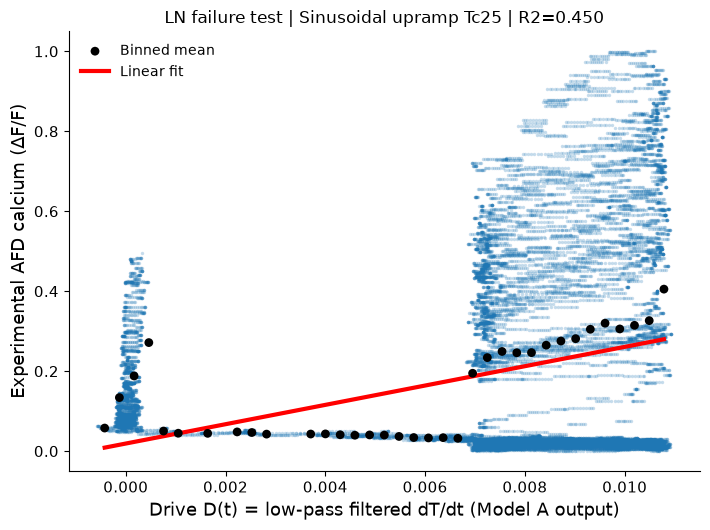

In [5]:
# 5. LN test: calcium vs leaky-derivative drive D(t) for one randomly chosen worm
#    Binned mean and linear fit, using the per-worm Model A fits (nothing is refit).

# Settings
USE_ALL_REPS = True          # False: use only REP_TO_USE
REP_TO_USE = 0
RANDOM_SEED = 0

SUBSAMPLE_MAX_POINTS = 60000
SCATTER_S = 6
SCATTER_ALPHA = 0.25

N_D_BINS_LN = 40
MIN_POINTS_PER_BIN = 20
SUMMARY_POINT_SIZE = 40

_modelA = fit_df[(fit_df["model_id"] == "deriv_tau") & np.isfinite(fit_df["R2"])]
tauD_by_rep = {int(r["rep_idx"]): float(r["tauD"]) for _, r in _modelA.iterrows()}

rep_indices = list(range(n_worms)) if USE_ALL_REPS else [int(REP_TO_USE)]
valid_reps = [r for r in rep_indices if r in tauD_by_rep]
if len(valid_reps) == 0:
    raise RuntimeError("No valid replicates found.")

rng = np.random.default_rng(RANDOM_SEED)
rep_idx = int(rng.choice(valid_reps, size=1, replace=False)[0])
print(f"Selected random worm/replicate: {rep_idx}")

Calcium = np.asarray(Ca_mat[:, rep_idx], dtype=float)
D = model_a_baseline_derivative(Time, Temp, tauD_by_rep[rep_idx])

m = FIT_MASK & np.isfinite(D) & np.isfinite(Calcium)
if np.sum(m) < 20:
    raise RuntimeError("Too few valid points.")
D_all = D[m]
Ca_all = Calcium[m]
print(f"LN-test points collected (worm {rep_idx}): {len(D_all)}")

# Subsample for plotting
n = len(D_all)
if (SUBSAMPLE_MAX_POINTS is not None) and (n > SUBSAMPLE_MAX_POINTS):
    idx = np.random.default_rng(0).choice(n, size=int(SUBSAMPLE_MAX_POINTS), replace=False)
    D_plot, Ca_plot = D_all[idx], Ca_all[idx]
else:
    D_plot, Ca_plot = D_all, Ca_all

# LN-style binning
bins = np.linspace(np.nanmin(D_all), np.nanmax(D_all), int(N_D_BINS_LN))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
Ca_mean = np.full(len(bin_centers), np.nan)
for k, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    mk = (D_all >= lo) & (D_all < hi) & np.isfinite(Ca_all)
    if np.sum(mk) >= MIN_POINTS_PER_BIN:
        Ca_mean[k] = np.nanmean(Ca_all[mk])

# Linear fit to the binned means
fit_mask = np.isfinite(bin_centers) & np.isfinite(Ca_mean)
if np.sum(fit_mask) >= 2:
    x_fit = bin_centers[fit_mask]
    y_fit = Ca_mean[fit_mask]
    a, b = np.polyfit(x_fit, y_fit, deg=1)
    y_pred = a * x_fit + b
    ss_res = np.sum((y_fit - y_pred) ** 2)
    ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
    R2 = np.nan if ss_tot == 0 else (1.0 - ss_res / ss_tot)
else:
    a, b, R2 = np.nan, np.nan, np.nan

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.scatter(D_plot, Ca_plot, s=SCATTER_S, alpha=SCATTER_ALPHA, color="#1f77b4", linewidths=0)
ax.scatter(bin_centers[fit_mask], Ca_mean[fit_mask], s=SUMMARY_POINT_SIZE, c="black",
           edgecolors="none", zorder=5, label="Binned mean")
if np.isfinite(a):
    x_line = np.linspace(np.nanmin(x_fit), np.nanmax(x_fit), 200)
    ax.plot(x_line, a * x_line + b, color="red", linewidth=3.0, label="Linear fit")

ax.set_xlabel("Drive D(t) = low-pass filtered dT/dt (Model A output)", fontsize=13)
ax.set_ylabel("Experimental AFD calcium (ΔF/F)", fontsize=13)
ax.tick_params(axis="both", labelsize=11)
r2_str = "NA" if not np.isfinite(R2) else f"{R2:.3f}"
ax.set_title(f"LN failure test | {dataset} | R2={r2_str}", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
save_svg(fig, f"{safe_label(dataset)}_LN_test.svg")
plt.show()

## Worm-level cross-validation

Biological parameters (including T_ref in Models B and E) are fit on the training worms only and then frozen; on each held-out worm only the affine readout (a, b) is fit. Each model is compared with Model F by an unpaired two-sided Mann-Whitney U test on the held-out R² values, with Bonferroni correction for the five comparisons (Holm-corrected p-values are reported as well). The significance labels in the figure use the corrected p-values. A fold-level table (difference of fold-mean held-out R² and number of folds in which Model F is higher) is reported descriptively.

CROSS-VALIDATED MODEL COMPARISON - Models A-F - Sinusoidal upramp Tc25
Mode: kfold; folds: 5; worms: 17; 300 Optuna trials per training fold and model

Fold 1/5: train n=13, test n=4
  Model A: train mean R2=0.0335; test mean R2=0.0340
  Model B: train mean R2=0.1560; test mean R2=0.1403
  Model C: train mean R2=0.0335; test mean R2=0.0340
  Model D: train mean R2=0.5674; test mean R2=0.5778
  Model E: train mean R2=0.6629; test mean R2=0.6153
  Model F: train mean R2=0.8275; test mean R2=0.8144

Fold 2/5: train n=13, test n=4
  Model A: train mean R2=0.0354; test mean R2=0.0280
  Model B: train mean R2=0.1590; test mean R2=0.1306
  Model C: train mean R2=0.0354; test mean R2=0.0280
  Model D: train mean R2=0.5884; test mean R2=0.5126
  Model E: train mean R2=0.6286; test mean R2=0.6691
  Model F: train mean R2=0.8200; test mean R2=0.8403

Fold 3/5: train n=14, test n=3
  Model A: train mean R2=0.0346; test mean R2=0.0292
  Model B: train mean R2=0.1494; test mean R2=0.1662
  Model C: 

,model_id,model_name,description,n,mean_R2,median_R2,std_R2,sem_R2
0,deriv_tau,Model A,Baseline derivative,17,0.033644,0.022030,0.032228,0.007816
1,fcd_tref,Model B,"FCD, fitted T_ref below stimulus",17,0.152279,0.152564,0.030271,0.007342
2,feedback_norm,Model C,Feedback-like divisive normalization,17,0.033645,0.022033,0.032228,0.007816
3,threshold_sig,Model D,Sigmoid/threshold,17,0.566826,0.595620,0.123522,0.029958
4,act_threshold_relaxed,Model E,"Adaptive threshold, T_ref within range",17,0.643391,0.645548,0.054092,0.013119
5,full_gamma,Model F,Goal-dependent gain,17,0.815909,0.829371,0.093112,0.022583



Best-fit shared biological parameters per fold:


,fold,model_id,model_name,description,train_n,test_n,train_mean_R2_objective,test_mean_R2,tauD,T_ref_gap_FCD,tauA,norm_k,T_thr,sigmoid_slope,tau_ACT,K_ACT,T_ref_ACT,T_on,k_shape,k_scale
0,1,deriv_tau,Model A,Baseline derivative,13,4,0.033538,0.033986,59.999823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,fcd_tref,Model B,"FCD, fitted T_ref below stimulus",13,4,0.156038,0.140321,59.978759,1.095075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,feedback_norm,Model C,Feedback-like divisive normalization,13,4,0.033539,0.033987,59.998806,NaN,7.890845,0.010013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,threshold_sig,Model D,Sigmoid/threshold,13,4,0.567407,0.577764,49.401449,NaN,NaN,NaN,20.195950,9.364661,NaN,NaN,NaN,NaN,NaN,NaN
4,1,act_threshold_relaxed,Model E,"Adaptive threshold, T_ref within range",13,4,0.662945,0.615350,NaN,NaN,NaN,NaN,NaN,NaN,56.027376,14.745216,23.125303,NaN,NaN,NaN
5,1,full_gamma,Model F,Goal-dependent gain,13,4,0.827514,0.814363,47.975489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.016010,1.918871,1.724197
6,2,deriv_tau,Model A,Baseline derivative,13,4,0.035371,0.028029,59.999241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2,fcd_tref,Model B,"FCD, fitted T_ref below stimulus",13,4,0.159007,0.130556,59.996794,1.177307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2,feedback_norm,Model C,Feedback-like divisive normalization,13,4,0.035372,0.028031,59.999376,NaN,13.950709,0.010029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2,threshold_sig,Model D,Sigmoid/threshold,13,4,0.588430,0.512612,55.055414,NaN,NaN,NaN,20.105435,9.725452,NaN,NaN,NaN,NaN,NaN,NaN



Unpaired held-out comparisons against Model F (two-sided Mann-Whitney U test).
5 comparisons; p_bonferroni = min(1, 5 x p); labels use the bonferroni-corrected p.


,comparison,other_model_description,n_reference,n_other,delta_mean_R2,delta_median_R2,higher_R2,mannwhitney_U,mannwhitney_p,p_bonferroni,p_holm,label
0,Model F vs Model A,Baseline derivative,17,17,0.782265,0.807341,Model F,289.0,7.054088e-07,0.000004,0.000004,***
1,Model F vs Model B,"FCD, fitted T_ref below stimulus",17,17,0.663630,0.676807,Model F,289.0,7.054088e-07,0.000004,0.000004,***
2,Model F vs Model C,Feedback-like divisive normalization,17,17,0.782264,0.807338,Model F,289.0,7.054088e-07,0.000004,0.000004,***
3,Model F vs Model D,Sigmoid/threshold,17,17,0.249082,0.233751,Model F,278.0,4.627805e-06,0.000023,0.000009,***
4,Model F vs Model E,"Adaptive threshold, T_ref within range",17,17,0.172518,0.183823,Model F,269.0,1.946002e-05,0.000097,0.000019,***



Fold-level descriptive check (Model F fold mean - other model fold mean, held-out R2):


,comparison,mean_fold_delta_R2,min_fold_delta_R2,max_fold_delta_R2,folds_Model_F_higher
0,Model F - Model A,0.780388,0.662396,0.860786,5/5
1,Model F - Model B,0.659859,0.541689,0.724723,5/5
2,Model F - Model C,0.780387,0.662396,0.860785,5/5
3,Model F - Model D,0.244671,0.217176,0.327732,5/5
4,Model F - Model E,0.170837,0.099098,0.239101,5/5


Saved results/Sinusoidal_upramp_Tc25_held_out_R2_Models_A_to_F.svg


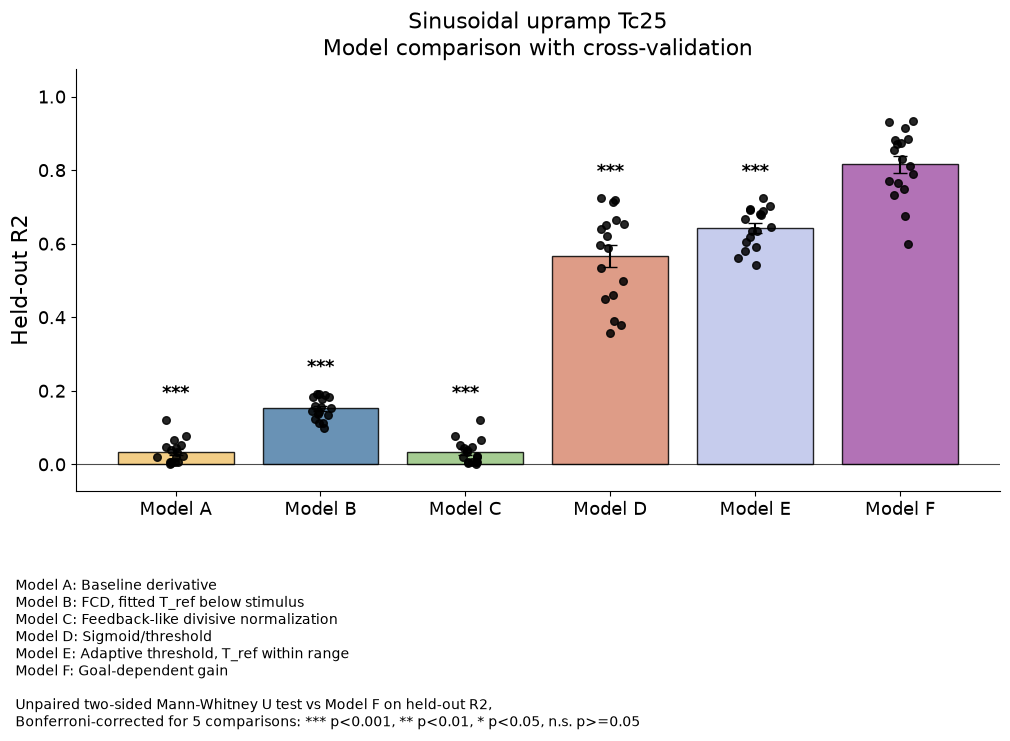

In [6]:
# 6. Worm-level cross-validation: Models A-F
#
# In each fold the biological parameters are fit on the training worms only and then frozen;
# on each held-out worm only the affine readout (a, b) is fit. Each model is compared with
# Model F using an unpaired two-sided Mann-Whitney U test on the held-out R2 values,
# corrected for multiple comparisons.

def make_cv_splits(n):
    """Worm-level k-fold or leave-one-out splits."""
    indices = np.arange(n)
    if CV_MODE.lower() == "loo":
        return [(np.setdiff1d(indices, [i]), np.array([i], dtype=int)) for i in indices]
    if CV_MODE.lower() == "kfold":
        n_splits = int(min(CV_N_SPLITS, n))
        if n_splits < 2:
            raise ValueError("Need at least 2 worms/folds for k-fold cross-validation.")
        shuffled = indices.copy()
        np.random.default_rng(CV_RANDOM_SEED).shuffle(shuffled)
        splits = []
        for test_idx in np.array_split(shuffled, n_splits):
            test_idx = np.asarray(test_idx, dtype=int)
            splits.append((np.setdiff1d(indices, test_idx), test_idx))
        return splits
    raise ValueError('CV_MODE must be "kfold" or "loo"')


def mean_r2_across_worms(C_model, worm_indices):
    """
    Mean R2 of ONE latent trace across a set of worms, fitting only a, b per worm.
    The trace depends on the stimulus and the biological parameters, not on the worm,
    so it is built once by the caller and reused for every worm.
    """
    if not trace_is_usable(C_model):
        return -1e9
    r2_vals = []
    for idx in worm_indices:
        Calcium = np.asarray(Ca_mat[:, idx], dtype=float)
        if np.isfinite(Calcium).sum() < 10:
            continue
        R2 = affine_score(C_model, Calcium)[0]
        if np.isfinite(R2):
            r2_vals.append(R2)
    return float(np.mean(r2_vals)) if r2_vals else -1e9


class CVTrainingObjective:
    """Training objective: mean R2 across the training worms for shared biological parameters."""
    def __init__(self, model_id, train_indices):
        self.model_id = model_id
        self.train_indices = np.asarray(train_indices, dtype=int)

    def __call__(self, trial):
        params = suggest_params(trial, self.model_id)
        score = mean_r2_across_worms(build_model(self.model_id, params), self.train_indices)
        return float(score) if np.isfinite(score) else -1e9


splits_cv = make_cv_splits(n_worms)

print("=" * 80)
print(f"CROSS-VALIDATED MODEL COMPARISON - Models A-F - {dataset}")
print(f"Mode: {CV_MODE}; folds: {len(splits_cv)}; worms: {n_worms}; "
      f"{N_TRIALS_CV} Optuna trials per training fold and model")
print("=" * 80)

cv_rows = []
cv_param_rows = []

for fold_i, (train_idx, test_idx) in enumerate(splits_cv, start=1):
    print(f"\nFold {fold_i}/{len(splits_cv)}: train n={len(train_idx)}, test n={len(test_idx)}")

    for cfg in MODEL_CONFIGS:
        model_id = cfg["id"]

        # the seed tag "alt_cv" is kept so that the results are reproducible
        seed_val = stable_seed(dataset, "alt_cv", fold_i, model_id, base=CV_RANDOM_SEED)
        set_all_seeds(seed_val)
        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=seed_val))
        study.optimize(
            CVTrainingObjective(model_id, train_idx),
            n_trials=N_TRIALS_CV,
            show_progress_bar=SHOW_OPTUNA_PROGRESS,
            n_jobs=1,
        )
        best_params = dict(study.best_params)
        train_score = float(study.best_value)

        # Held-out worms: biological parameters frozen, only (a, b) fit per worm
        C_frozen = build_model(model_id, best_params)
        test_scores = []
        for idx in test_idx:
            R2, a, b, _ = affine_score(C_frozen, np.asarray(Ca_mat[:, idx], dtype=float))
            test_scores.append(R2)
            cv_rows.append({
                "fold": int(fold_i), "rep_idx": int(idx), "rep_name": str(rep_cols[idx]),
                "model_id": model_id, "model_name": cfg["name"], "description": cfg["description"],
                "R2": R2, "a": a, "b": b,
            })

        cv_param_rows.append({
            "fold": int(fold_i), "model_id": model_id, "model_name": cfg["name"],
            "description": cfg["description"],
            "train_n": int(len(train_idx)), "test_n": int(len(test_idx)),
            "train_mean_R2_objective": float(train_score),
            "test_mean_R2": float(np.nanmean(test_scores)),
            **{k: float(v) for k, v in best_params.items()},
        })
        print(f"  {cfg['name']}: train mean R2={train_score:.4f}; test mean R2={np.nanmean(test_scores):.4f}")

cv_fit_df = pd.DataFrame(cv_rows)
cv_param_df = pd.DataFrame(cv_param_rows)
for _name in sorted({n for names in PARAM_NAMES.values() for n in names}):
    if _name not in cv_param_df.columns:
        cv_param_df[_name] = np.nan

# Summary table
cv_summary_rows = []
for cfg in MODEL_CONFIGS:
    vals = cv_fit_df.loc[cv_fit_df["model_id"] == cfg["id"], "R2"].to_numpy(dtype=float)
    vals_f = vals[np.isfinite(vals)]
    cv_summary_rows.append({
        "model_id": cfg["id"], "model_name": cfg["name"], "description": cfg["description"],
        "n": int(vals_f.size),
        "mean_R2": float(np.mean(vals_f)) if vals_f.size else np.nan,
        "median_R2": float(np.median(vals_f)) if vals_f.size else np.nan,
        "std_R2": float(np.std(vals_f, ddof=1)) if vals_f.size > 1 else np.nan,
        "sem_R2": float(np.std(vals_f, ddof=1) / np.sqrt(vals_f.size)) if vals_f.size > 1 else np.nan,
    })
cv_summary_df = pd.DataFrame(cv_summary_rows)
print("\nCross-validated summary (held-out worms)")
display(cv_summary_df)

print("\nBest-fit shared biological parameters per fold:")
display(cv_param_df)

# Unpaired comparisons against Model F (one per alternative model: Models A-E)
cv_tests_df = unpaired_tests_vs_reference(cv_fit_df)
n_comparisons = int(np.isfinite(cv_tests_df["mannwhitney_p"]).sum())
label_by_model_id = dict(zip(cv_tests_df["model_id"], cv_tests_df["label"]))

print(f"\nUnpaired held-out comparisons against {REFERENCE_MODEL_NAME} (two-sided Mann-Whitney U test).")
print(f"{n_comparisons} comparisons; p_bonferroni = min(1, {n_comparisons} x p); "
      f"labels use the {MULTIPLE_COMPARISON_METHOD}-corrected p.")
display(cv_tests_df.drop(columns="model_id"))

_p_used = cv_tests_df["p_bonferroni" if MULTIPLE_COMPARISON_METHOD.lower() == "bonferroni" else "p_holm"]
_better = cv_tests_df[(_p_used < 0.05) & (cv_tests_df["delta_median_R2"] < 0)]
for _, _r in _better.iterrows():
    print(f"NOTE: {MODEL_NAME[_r['model_id']]} has HIGHER held-out R2 than {REFERENCE_MODEL_NAME} "
          f"(difference of medians {-_r['delta_median_R2']:.3f}); the test is two-sided, so its label "
          f"marks a difference in favor of {MODEL_NAME[_r['model_id']]}.")

# Fold-level descriptive check (no additional hypothesis test).
# Worms in one test fold share one set of trained parameters; delta = Model F fold mean - other fold mean.
_fold_mean = cv_fit_df.groupby(["fold", "model_id"])["R2"].mean().unstack("model_id")
fold_rows = []
for cfg in MODEL_CONFIGS:
    if cfg["id"] == REFERENCE_MODEL_ID:
        continue
    d = (_fold_mean[REFERENCE_MODEL_ID] - _fold_mean[cfg["id"]]).dropna()
    fold_rows.append({
        "comparison": f"{REFERENCE_MODEL_NAME} - {cfg['name']}",
        "mean_fold_delta_R2": float(d.mean()),
        "min_fold_delta_R2": float(d.min()),
        "max_fold_delta_R2": float(d.max()),
        f"folds_{REFERENCE_MODEL_NAME.replace(' ', '_')}_higher": f"{int((d > 0).sum())}/{len(d)}",
    })
cv_fold_delta_df = pd.DataFrame(fold_rows)
print(f"\nFold-level descriptive check ({REFERENCE_MODEL_NAME} fold mean - other model fold mean, held-out R2):")
display(cv_fold_delta_df)

# Figure: held-out R2 (bars: mean +/- SEM; points: individual held-out worms)
r2_arrays = [
    cv_fit_df.loc[cv_fit_df["model_id"] == mid, "R2"].to_numpy(dtype=float)
    for mid in MODEL_IDS
]
means = np.array([np.nanmean(v) for v in r2_arrays])
sems = np.array([
    np.nanstd(v[np.isfinite(v)], ddof=1) / np.sqrt(np.isfinite(v).sum())
    if np.isfinite(v).sum() > 1 else 0.0
    for v in r2_arrays
])
x = np.arange(len(MODEL_IDS))

fig, ax = plt.subplots(figsize=(10.2, 5.4))
ax.bar(
    x, means, yerr=sems, capsize=5,
    color=[MODEL_COLORS[mid] for mid in MODEL_IDS], edgecolor="black",
    linewidth=1.0, alpha=0.85, ecolor="black", zorder=2,
)

rng = np.random.default_rng(0)
all_finite_vals = []
top_by_model = []
for i, arr in enumerate(r2_arrays):
    vals = arr[np.isfinite(arr)]
    all_finite_vals.extend(vals.tolist())
    top_val = np.nanmax(vals) if vals.size else means[i]
    top_by_model.append(max(top_val, means[i] + sems[i] if np.isfinite(sems[i]) else means[i]))
    jitter = rng.normal(0.0, 0.055, size=vals.size)
    ax.scatter(np.full(vals.size, x[i]) + jitter, vals, color="black", s=30, alpha=0.85, zorder=3)

# Significance label above every non-reference bar
finite_all = np.asarray(all_finite_vals, dtype=float)
data_min = float(np.nanmin(finite_all)) if finite_all.size else 0.0
data_max = float(np.nanmax(finite_all)) if finite_all.size else 1.0
yrange = max(0.1, data_max - data_min)
text_offset = 0.05 * yrange
for i, mid in enumerate(MODEL_IDS):
    label = label_by_model_id.get(mid, "")
    if label:
        ax.text(x[i], top_by_model[i] + text_offset, label,
                ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([MODEL_NAME[mid] for mid in MODEL_IDS], fontsize=13)
ax.set_ylabel("Held-out R2", fontsize=16)
ax.set_title(f"{dataset}\nModel comparison with cross-validation", fontsize=16, pad=10)
ax.tick_params(axis="y", labelsize=13)

y_top_needed = max(max(top_by_model) + 2.0 * text_offset, 1.0)
y_bottom_needed = min(0.0, data_min - 0.08 * yrange)
ax.set_ylim(y_bottom_needed, y_top_needed + 0.05 * yrange)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

desc_text = "\n".join(f"{MODEL_NAME[mid]}: {MODEL_DESCRIPTION[mid]}" for mid in MODEL_IDS)
desc_text += (
    f"\n\nUnpaired two-sided Mann-Whitney U test vs {REFERENCE_MODEL_NAME} on held-out R2,\n"
    f"{MULTIPLE_COMPARISON_METHOD.capitalize()}-corrected for {n_comparisons} comparisons: "
    "*** p<0.001, ** p<0.01, * p<0.05, n.s. p>=0.05"
)
fig.text(0.02, -0.08, desc_text, ha="left", va="top", fontsize=10)
fig.tight_layout()
save_svg(fig, f"{safe_label(dataset)}_held_out_R2_Models_A_to_F.svg")
plt.show()

Saved results/Sinusoidal_upramp_Tc25_held_out_R2_Model_A_vs_Model_F.svg


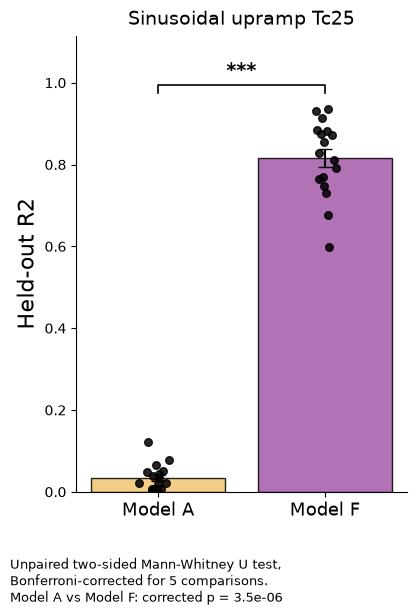

In [7]:
# 7. Held-out R2 of Model A and Model F (Fig. 5F'/G')
#    Uses the cross-validation results of section 6. The label is the corrected
#    Mann-Whitney p of Model A vs Model F, as in the all-model figure above.

FIG5_MODEL_IDS = ["deriv_tau", "full_gamma"]      # Model A, Model F
FIG5_FIGSIZE = (4.2, 5.4)

_arrays5 = [cv_fit_df.loc[cv_fit_df["model_id"] == mid, "R2"].to_numpy(dtype=float)
            for mid in FIG5_MODEL_IDS]
_means5 = [mean_sem(v)[0] for v in _arrays5]
_sems5 = [mean_sem(v)[1] for v in _arrays5]
_x5 = np.arange(len(FIG5_MODEL_IDS))

fig5, ax5 = plt.subplots(figsize=FIG5_FIGSIZE)
ax5.bar(_x5, _means5, yerr=_sems5, capsize=5, color=[MODEL_COLORS[m] for m in FIG5_MODEL_IDS],
        edgecolor="black", linewidth=1.0, alpha=0.85, ecolor="black", zorder=2)
_rng5 = np.random.default_rng(0)
_top5 = []
for i, v in enumerate(_arrays5):
    v = v[np.isfinite(v)]
    ax5.scatter(np.full(v.size, _x5[i]) + _rng5.normal(0.0, 0.05, size=v.size), v,
                color="black", s=30, alpha=0.85, zorder=3)
    _top5.append(max(float(np.max(v)), _means5[i] + _sems5[i]))

_label5 = label_by_model_id.get("deriv_tau", "")
_ybar = max(_top5) + 0.06
ax5.plot([_x5[0], _x5[0], _x5[1], _x5[1]], [_ybar - 0.02, _ybar, _ybar, _ybar - 0.02], color="black", linewidth=1.2)
ax5.text(0.5 * (_x5[0] + _x5[1]), _ybar + 0.01, _label5, ha="center", va="bottom", fontsize=14, fontweight="bold")
ax5.set_xticks(_x5)
ax5.set_xticklabels([MODEL_NAME[m] for m in FIG5_MODEL_IDS], fontsize=13)
ax5.set_ylabel("Held-out R2", fontsize=16)
ax5.set_ylim(0.0, max(1.0, _ybar + 0.12))
ax5.set_title(f"{dataset}", fontsize=14, pad=8)
ax5.spines["top"].set_visible(False)
ax5.spines["right"].set_visible(False)
fig5.text(0.02, -0.04,
          f"Unpaired two-sided Mann-Whitney U test,\nBonferroni-corrected for {n_comparisons} comparisons.\n"
          f"Model A vs Model F: corrected p = "
          f"{float(cv_tests_df.loc[cv_tests_df['model_id'] == 'deriv_tau', 'p_bonferroni'].iloc[0]):.2g}",
          ha="left", va="top", fontsize=9)
fig5.tight_layout()
save_svg(fig5, f"{safe_label(dataset)}_held_out_R2_Model_A_vs_Model_F.svg")
plt.show()

In [8]:
# 8. Cross-validation parameter stability (Table S2)
#
# For every fitted biological parameter: the spread across training folds and how close
# the fitted values lie to the limits of the predefined search range. Uses cv_param_df.

BOUND_TOLERANCE_FRACTION = 0.05   # "at a bound" = within 5% of the search range (log range for log-sampled parameters)

stability_rows = []
for cfg in MODEL_CONFIGS:
    mid = cfg["id"]
    fold_df = cv_param_df[cv_param_df["model_id"] == mid]
    for name, low, high, log in PARAM_SPECS[mid]:
        vals = fold_df[name].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        position = (np.log(vals / low) / np.log(high / low)) if log else ((vals - low) / (high - low))
        stability_rows.append({
            "model": cfg["name"], "parameter": name,
            "search_low": low, "search_high": high, "log_sampled": log,
            "n_folds": int(vals.size),
            "mean": float(np.mean(vals)),
            "sd": float(np.std(vals, ddof=1)) if vals.size > 1 else np.nan,
            "min": float(np.min(vals)), "max": float(np.max(vals)),
            "n_folds_at_lower_bound": int(np.sum(position <= BOUND_TOLERANCE_FRACTION)),
            "n_folds_at_upper_bound": int(np.sum(position >= 1.0 - BOUND_TOLERANCE_FRACTION)),
        })

cv_param_stability_df = pd.DataFrame(stability_rows)
print(f"Cross-validation parameter stability - {dataset}")
print(f"'At a bound' = within {100 * BOUND_TOLERANCE_FRACTION:.0f}% of the search range from that limit.")
print("For Model B, T_ref_gap_FCD is the distance of T_ref below the coldest stimulus temperature.")
display(cv_param_stability_df)

_pinned = cv_param_stability_df[
    (cv_param_stability_df["n_folds_at_lower_bound"] == cv_param_stability_df["n_folds"])
    | (cv_param_stability_df["n_folds_at_upper_bound"] == cv_param_stability_df["n_folds"])
]
if len(_pinned):
    print("\nParameters at the same search-range limit in EVERY fold (their near-zero variance reflects the limit):")
    for _, _r in _pinned.iterrows():
        _side = "lower" if _r["n_folds_at_lower_bound"] == _r["n_folds"] else "upper"
        _limit = _r["search_low"] if _side == "lower" else _r["search_high"]
        print(f"  {_r['model']}  {_r['parameter']}: {_side} limit {_limit:g}; "
              f"fitted {_r['min']:.4f} to {_r['max']:.4f}")
else:
    print("\nNo parameter sits at the same search-range limit in every fold.")

Cross-validation parameter stability - Sinusoidal upramp Tc25
'At a bound' = within 5% of the search range from that limit.
For Model B, T_ref_gap_FCD is the distance of T_ref below the coldest stimulus temperature.


,model,parameter,search_low,search_high,log_sampled,n_folds,mean,sd,min,max,n_folds_at_lower_bound,n_folds_at_upper_bound
0,Model A,tauD,40.000000,60.000000,True,5,59.999762,0.000307,59.999241,59.999992,0,5
1,Model B,tauD,40.000000,60.000000,True,5,59.993034,0.008166,59.978759,59.998333,0,5
2,Model B,T_ref_gap_FCD,0.500000,284.963835,True,5,1.118313,0.033614,1.095075,1.177307,0,0
3,Model C,tauD,40.000000,60.000000,True,5,59.999164,0.000380,59.998735,59.999617,0,5
4,Model C,tauA,1.000000,300.000000,True,5,9.664395,3.401105,5.710897,13.950709,0,0
5,Model C,norm_k,0.010000,200.000000,True,5,0.010324,0.000418,0.010013,0.010991,5,0
6,Model D,tauD,40.000000,60.000000,True,5,50.462883,4.668983,43.038927,55.055414,0,0
7,Model D,T_thr,9.963835,29.991655,False,5,20.131900,0.048672,20.092881,20.195950,0,0
8,Model D,sigmoid_slope,0.050000,25.000000,True,5,10.491365,1.600108,9.364661,13.170439,0,0
9,Model E,tau_ACT,40.000000,60.000000,True,5,55.071913,5.024341,46.948177,59.865754,0,1



Parameters at the same search-range limit in EVERY fold (their near-zero variance reflects the limit):
  Model A  tauD: upper limit 60; fitted 59.9992 to 60.0000
  Model B  tauD: upper limit 60; fitted 59.9788 to 59.9983
  Model C  tauD: upper limit 60; fitted 59.9987 to 59.9996
  Model C  norm_k: lower limit 0.01; fitted 0.0100 to 0.0110


## Diagnostics of the reference-temperature models (B and E)

- **Model B:** variation of 1/T_K(t) over the stimulus, similarity of a Kelvin-scale drive to the Model A drive, and the fitted T_ref relative to its constraint
- **Model E:** fitted T_ref relative to its bounds, and comparison of the fitted model output with a rectified leaky derivative of temperature clipped at T_ref

In [9]:
# 9. Diagnostics of the reference-temperature models (Models B and E)
#    Uses fit_df (per-worm fits) and cv_param_df (cross-validation folds); nothing is refit.

print("=" * 80)
print(f"Model B (fold-change detection) diagnostics - {dataset}")
print("=" * 80)

# (a) Variation of a Kelvin-scale normalization over the stimulus (diagnostic only, not a fitted model)
T_scored = Temp[FIT_MASK]
inv_TK = 1.0 / (T_scored + 273.0)
inv_TK_var_pct = 100.0 * (inv_TK.max() - inv_TK.min()) / inv_TK.mean()
tau_D_ref = float(np.nanmedian(fit_df.loc[fit_df["model_id"] == "deriv_tau", "tauD"]))
drive_A = model_a_baseline_derivative(Time, Temp, tau_D_ref)[FIT_MASK]
drive_K = fcd_kelvin_drive(Time, Temp, tau_D_ref)[FIT_MASK]
r_AK = float(np.corrcoef(drive_A, drive_K)[0, 1])
print(f"Stimulus: {T_scored.min():.2f}-{T_scored.max():.2f} C -> T_K = "
      f"{T_scored.min() + 273.0:.2f}-{T_scored.max() + 273.0:.2f} K")
print(f"1/T_K(t) varies by {inv_TK_var_pct:.2f}% across the stimulus.")
print(f"Correlation of the Kelvin-form drive and the Model A (baseline derivative) drive at tauD = {tau_D_ref:.1f} s: r = {r_AK:.6f}")

# (b) Fitted reference temperature of Model B
fcd_tref_upper = T_MIN_FULL - FCD_MIN_GAP_C


def _tref_fcd_summary(gaps, label):
    tref = T_MIN_FULL - np.asarray(gaps, dtype=float)
    tref = tref[np.isfinite(tref)]
    return {
        "set": label, "n": int(tref.size),
        "median_T_ref_C": float(np.median(tref)),
        "min_T_ref_C": float(np.min(tref)), "max_T_ref_C": float(np.max(tref)),
        "median_distance_to_upper_bound_C": float(np.median(fcd_tref_upper - tref)),
        "n_within_0.05C_of_upper_bound": int(np.sum(np.abs(tref - fcd_tref_upper) < 0.05)),
        "n_within_5C_of_minus_273C": int(np.sum(tref < -268.0)),
    }


fcd_tref_table = pd.DataFrame([
    _tref_fcd_summary(fit_df.loc[fit_df["model_id"] == "fcd_tref", "T_ref_gap_FCD"], "per-worm fits"),
    _tref_fcd_summary(cv_param_df.loc[cv_param_df["model_id"] == "fcd_tref", "T_ref_gap_FCD"], "CV folds (shared)"),
])
print(f"\nModel B fitted T_ref (allowed range -273 to {fcd_tref_upper:.2f} C):")
display(fcd_tref_table)

print("\n" + "=" * 80)
print(f"Model E (adaptive threshold) diagnostics - {dataset}")
print("=" * 80)

# (c) Fitted reference temperature of Model E
act_rows = []
for mid, lo in [("act_threshold_relaxed", T_MIN_FULL)]:
    for label, df_ in [("per-worm fits", fit_df), ("CV folds (shared)", cv_param_df)]:
        tref = df_.loc[df_["model_id"] == mid, "T_ref_ACT"].to_numpy(dtype=float)
        tref = tref[np.isfinite(tref)]
        act_rows.append({
            "model": MODEL_NAME[mid], "set": label, "n": int(tref.size),
            "lower_bound_C": lo,
            "median_T_ref_C": float(np.median(tref)),
            "min_T_ref_C": float(np.min(tref)), "max_T_ref_C": float(np.max(tref)),
            "n_within_0.05C_of_lower_bound": int(np.sum(np.abs(tref - lo) < 0.05)),
            "n_T_ref_below_max_stimulus_T": int(np.sum(tref < T_MAX_FULL)),
        })
act_tref_table = pd.DataFrame(act_rows)
print(f"Stimulus range (full trace): {T_MIN_FULL:.2f}-{T_MAX_FULL:.2f} C")
display(act_tref_table)

# (d) Model E: comparison with a rectified leaky derivative of temperature clipped at T_ref.
#     When K_ACT >> S(t), Theta_inf ~= S and the output max(Theta - S, 0) equals
#     max(LPF(dTc/dt), 0) up to scale, with Tc = min(T, T_ref).


def _act_reduction_row(params, label):
    tau_act = float(params["tau_ACT"])
    k_act = float(params["K_ACT"])
    t_ref = float(params["T_ref_ACT"])
    act_output = model_e_adaptive_threshold(Time, Temp, tau_act, k_act, t_ref)
    T_clip = np.minimum(Temp, t_ref)
    rect = np.maximum(one_pole_filter(Time, numerical_derivative(Time, T_clip), tau_act), 0.0)
    xg, yr = act_output[FIT_MASK], rect[FIT_MASK]
    ok = np.isfinite(xg) & np.isfinite(yr)
    r = float(np.corrcoef(xg[ok], yr[ok])[0, 1]) if (np.std(xg[ok]) > 0 and np.std(yr[ok]) > 0) else np.nan
    return {
        "set": label, "T_ref_ACT": t_ref, "K_ACT": k_act, "tau_ACT": tau_act,
        "K_over_S_range": k_act / max(t_ref - T_MIN_FULL, 1e-6),
        "fraction_time_T_above_T_ref": float(np.mean(T_scored > t_ref)),
        "r_with_rectified_clipped_leaky_derivative": r,
    }


act_reduction_rows = []
for _, row in fit_df[fit_df["model_id"] == "act_threshold_relaxed"].iterrows():
    if np.isfinite(row["T_ref_ACT"]):
        act_reduction_rows.append(_act_reduction_row(row, f"worm {row['rep_name']}"))
for _, row in cv_param_df[cv_param_df["model_id"] == "act_threshold_relaxed"].iterrows():
    act_reduction_rows.append(_act_reduction_row(row, f"CV fold {int(row['fold'])}"))
act_reduction_df = pd.DataFrame(act_reduction_rows)

print("\nModel E reduction check (per worm and per CV fold):")
display(act_reduction_df)
print("\nModel E reduction summary:")
display(act_reduction_df[["K_over_S_range", "fraction_time_T_above_T_ref",
                         "r_with_rectified_clipped_leaky_derivative"]].describe().T)
print("K_over_S_range >> 1 together with r close to 1 indicates that the fitted Model E output approximates")
print("a rectified leaky temperature derivative that is gated off above T_ref.")

Model B (fold-change detection) diagnostics - Sinusoidal upramp Tc25
Stimulus: 11.96-27.99 C -> T_K = 284.96-300.99 K
1/T_K(t) varies by 5.45% across the stimulus.
Correlation of the Kelvin-form drive and the Model A (baseline derivative) drive at tauD = 60.0 s: r = 0.999289

Model B fitted T_ref (allowed range -273 to 11.46 C):


,set,n,median_T_ref_C,min_T_ref_C,max_T_ref_C,median_distance_to_upper_bound_C,n_within_0.05C_of_upper_bound,n_within_5C_of_minus_273C
0,per-worm fits,17,10.938525,8.981642,11.463608,0.525310,1,0
1,CV folds (shared),5,10.855667,10.786528,10.868760,0.608167,0,0



Model E (adaptive threshold) diagnostics - Sinusoidal upramp Tc25
Stimulus range (full trace): 11.96-27.99 C


,model,set,n,lower_bound_C,median_T_ref_C,min_T_ref_C,max_T_ref_C,n_within_0.05C_of_lower_bound,n_T_ref_below_max_stimulus_T
0,Model E,per-worm fits,17,11.963835,23.295772,22.022895,26.134599,0,17
1,Model E,CV folds (shared),5,11.963835,23.125303,23.074069,23.471029,0,5



Model E reduction check (per worm and per CV fold):


,set,T_ref_ACT,K_ACT,tau_ACT,K_over_S_range,fraction_time_T_above_T_ref,r_with_rectified_clipped_leaky_derivative
0,worm Rep_1,24.512339,32.580614,58.416375,2.596374,0.190194,0.398108
1,worm Rep_2,23.358590,16.537041,59.965529,1.451285,0.254660,0.355989
2,worm Rep_3,22.530404,8.293431,59.511769,0.784875,0.298932,0.301792
3,worm Rep_4,23.295772,16.662855,58.082930,1.470433,0.256408,0.357828
4,worm Rep_5,22.619227,10.763141,47.311893,1.010112,0.292767,0.319740
5,worm Rep_6,22.640612,7.147136,57.058935,0.669410,0.291456,0.276618
6,worm Rep_7,22.707258,5.826290,53.777649,0.542312,0.290583,0.248731
7,worm Rep_8,22.674702,8.419327,58.929608,0.786055,0.291068,0.296120
8,worm Rep_9,23.365498,15.302985,48.465589,1.342171,0.254078,0.332100
9,worm Rep_10,23.523295,18.856458,56.012742,1.631258,0.244612,0.361673



Model E reduction summary:


,count,mean,std,min,25%,50%,75%,max
K_over_S_range,22.0,1.803541,1.352514,0.542312,0.924798,1.440091,1.994959,6.404151
fraction_time_T_above_T_ref,22.0,0.254490,0.049307,0.103107,0.245024,0.263568,0.290947,0.326165
r_with_rectified_clipped_leaky_derivative,22.0,0.357758,0.055201,0.248731,0.322501,0.356908,0.394493,0.468267


K_over_S_range >> 1 together with r close to 1 indicates that the fitted Model E output approximates
a rectified leaky temperature derivative that is gated off above T_ref.


Saved results/Sinusoidal_upramp_Tc25_representative_models_A_to_F_Rep_17_2x3.svg


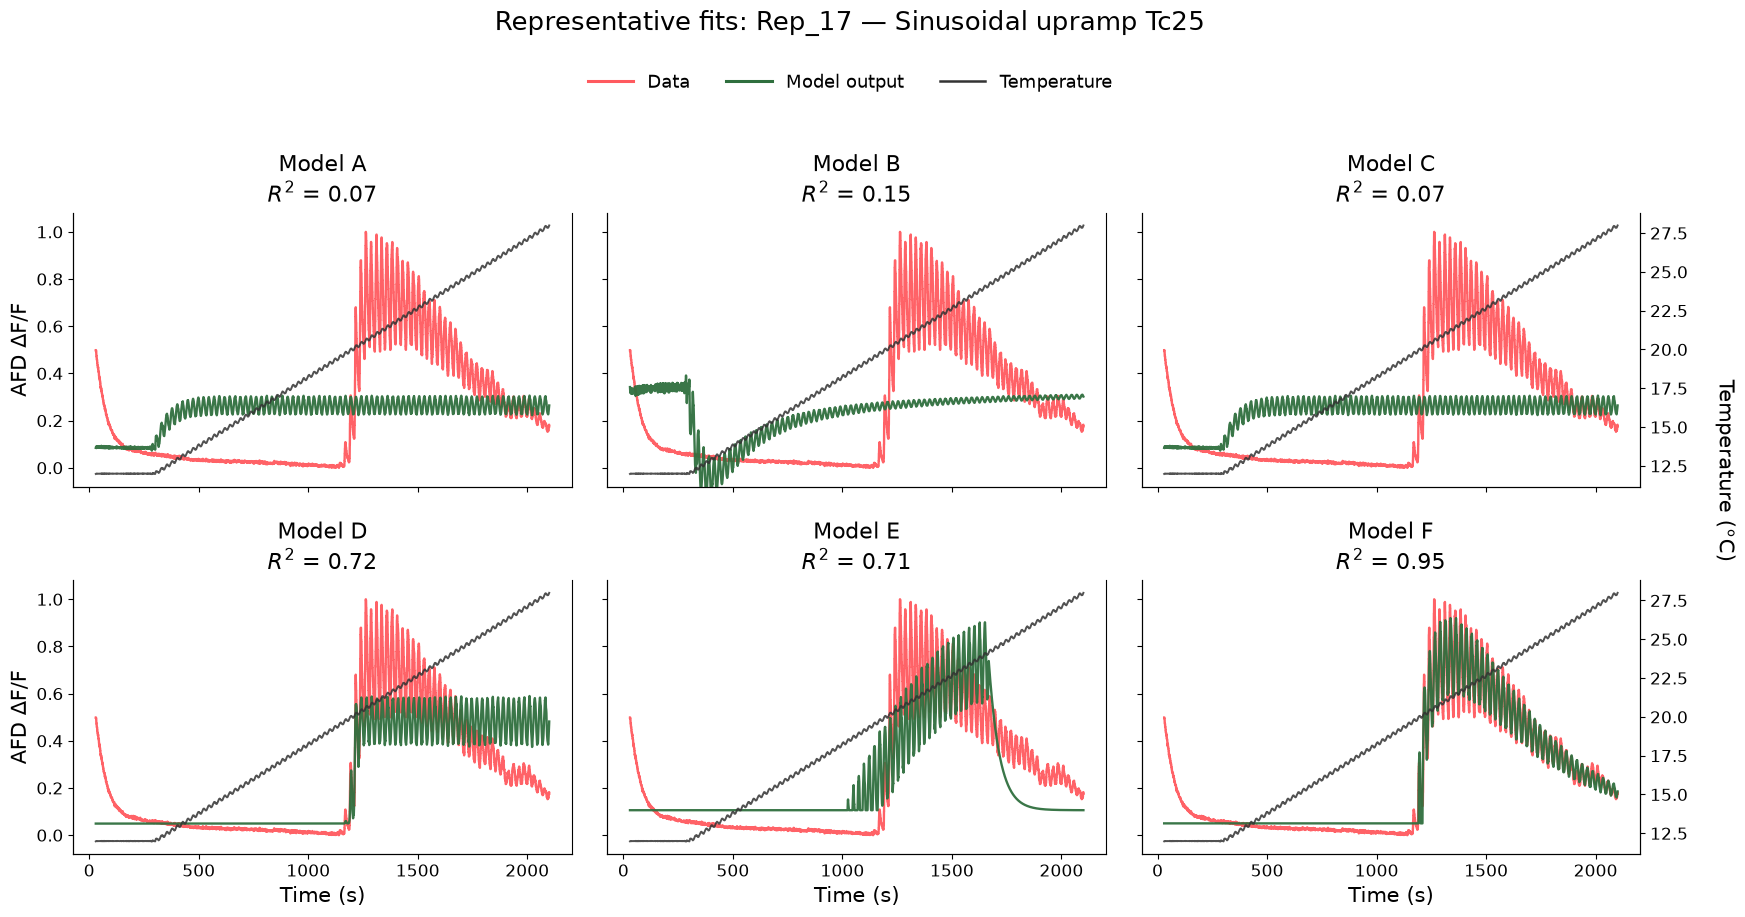

In [10]:
# 10. Representative fitted traces, Models A-F (Fig. S7A,B)
#     The representative worm is the one chosen in section 4; nothing is refit.

PANEL_DATA_COLOR = "#ff5a5f"
PANEL_FIT_COLOR = "#2f6f3e"
PANEL_TEMP_COLOR = "#333333"

# Common axis limits
_finite_y = Calcium_rep[np.isfinite(Calcium_rep)]
y_min = float(np.min(_finite_y)) if _finite_y.size else 0.0
y_max = float(np.max(_finite_y)) if _finite_y.size else 1.0
y_pad = 0.08 * max(1e-6, y_max - y_min)
_finite_t = Temp[np.isfinite(Temp)]
t_min = float(np.min(_finite_t)) if _finite_t.size else 0.0
t_max = float(np.max(_finite_t)) if _finite_t.size else 1.0
t_pad = 0.05 * max(1e-6, t_max - t_min)

# Top row: Models A, B, C. Bottom row: Models D, E, F.
MODEL_ORDER_A_TO_F = ["deriv_tau", "fcd_tref", "feedback_norm", "threshold_sig", "act_threshold_relaxed", "full_gamma"]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18.0, 9.5), sharex=True, sharey=True)

for plot_index, model_id in enumerate(MODEL_ORDER_A_TO_F):
    model_info = fit_lookup[model_id]
    row_index, column_index = divmod(plot_index, 3)
    ax = axes[row_index, column_index]

    ax.plot(Time, Calcium_rep, color=PANEL_DATA_COLOR, linewidth=1.7, alpha=0.95, label="Data", zorder=3)
    ax.plot(Time, model_info["fit"], color=PANEL_FIT_COLOR, linewidth=1.7, alpha=0.95,
            label="Model output", zorder=4)
    ax.set_title(f"{model_info['model_name']}\n$R^2$ = {model_info['R2']:.2f}", fontsize=16, pad=8)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.tick_params(axis="both", labelsize=12)
    ax.spines["top"].set_visible(False)
    if column_index == 0:
        ax.set_ylabel("AFD ΔF/F", fontsize=15)
    if row_index == 1:
        ax.set_xlabel("Time (s)", fontsize=15)

    ax_temperature = ax.twinx()
    ax_temperature.plot(Time, Temp, color=PANEL_TEMP_COLOR, linewidth=1.4, alpha=0.85, zorder=2)
    ax_temperature.set_ylim(t_min - t_pad, t_max + t_pad)
    ax_temperature.spines["top"].set_visible(False)
    if column_index == 2:
        ax_temperature.tick_params(axis="y", labelsize=12, right=True, labelright=True)
    else:
        ax_temperature.tick_params(axis="y", right=False, labelright=False, length=0)
        ax_temperature.spines["right"].set_visible(False)

fig.text(0.992, 0.50, "Temperature (°C)", va="center", ha="right", rotation=270, fontsize=15)

legend_handles = [
    Line2D([0], [0], color=PANEL_DATA_COLOR, linewidth=2.2, label="Data"),
    Line2D([0], [0], color=PANEL_FIT_COLOR, linewidth=2.2, label="Model output"),
    Line2D([0], [0], color=PANEL_TEMP_COLOR, linewidth=1.8, label="Temperature"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.935), ncol=3,
           frameon=False, fontsize=13, handlelength=2.5, columnspacing=2.0)
fig.suptitle(f"Representative fits: {rep_name} — {dataset}", fontsize=19, y=0.985)
fig.tight_layout(rect=[0.025, 0.025, 0.965, 0.895], h_pad=2.0, w_pad=2.2)
save_svg(fig, f"{safe_label(dataset)}_representative_models_A_to_F_{safe_label(rep_name)}_2x3.svg")
plt.show()